# La dieta keto aceleró los tumores... y el culpable no eran las cetonas

Le das a un ratón —de esos genéticamente propensos a los pólipos intestinales— una dieta cetogénica: mucha grasa, casi nada de azúcar. La misma dieta que se vende para adelgazar y "limpiar" el metabolismo.

Resultado: **más tumores, más grandes, y mueren antes.** Mediana de 18 tumores por ratón con keto, contra 7 con dieta normal.

Y aquí está lo raro: cuando los investigadores apagaron las cetonas —el sello químico de la dieta keto— los tumores siguieron igual. El acelerador era otra cosa.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

---

**Paper:** *Ketogenic diet mediates intestinal tumorigenesis through lipids not ketones* · Shay et al., **Nature** (2026)
**DOI:** [10.1038/s41586-026-10779-y](https://doi.org/10.1038/s41586-026-10779-y)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-17-keto-tumores/notebook.ipynb)

## De dónde salen estos datos

El escenario son ratones con una mutación en el gen *Apc* — el mismo defecto que tienen las personas con **poliposis adenomatosa familiar (FAP)**, una condición hereditaria que llena el intestino de pólipos y dispara el riesgo de cáncer desde joven. Son ratones que, dejados solos, ya desarrollan adenomas intestinales.

Sobre ese fondo, el equipo cruzó tres palancas:

- **Dieta** — cetogénica (KD, ~90% de calorías en grasa) contra una dieta control (CD).
- **Genética** — knockouts (ratones a los que se les apaga un gen concreto) para desactivar piezas específicas: la enzima que fabrica cetonas (*HMGCS2*), la que las quema, y la que oxida las grasas para sacarles energía (*CPT1A*).
- **Metabolismo** — midieron cetonas en sangre, contaron y midieron tumores, y siguieron la supervivencia.

La pregunta: si la dieta keto empeora los tumores, ¿es por las cetonas, o por la grasa misma? Abramos los datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_CONTROL = '#2563EB'    # azul CaM  — dieta control (CD) / genotipo protegido
COLOR_KETO    = '#DC2626'    # rojo      — dieta cetogénica (KD) / condición dañina
COLOR_RESCATE = '#059669'    # emerald   — el rescate genético (Cpt1a-iKO)
COLOR_REF     = '#D97706'    # amber     — referencias/umbral
FUENTE = 'Fuente: Shay et al. (2026), Nature | Datos: Nature Source Data (Figs 1 y 5)'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── Carga de los datos crudos del paper (Source Data) ──
bhb   = pd.read_csv('datos/fig1b_bhb.csv')              # β-hidroxibutirato KD vs CD
tnum  = pd.read_csv('datos/fig1i_tumor_number.csv')     # nº de tumores KD vs CD
tarea = pd.read_csv('datos/fig1j_tumor_area.csv')       # área tumoral KD vs CD
surv  = pd.read_csv('datos/fig1h_survival.csv')         # supervivencia KD vs CD
c_num = pd.read_csv('datos/fig5i_tumor_number_cpt1a.csv')  # nº tumores WT vs Cpt1a-iKO (bajo KD)
c_area= pd.read_csv('datos/fig5h_tumor_area_cpt1a.csv')    # área tumoral WT vs iKO (bajo KD)
c_srv = pd.read_csv('datos/fig5g_survival_cpt1a.csv')      # supervivencia WT vs iKO (bajo KD)

# ── Herramientas estadísticas ──
def cohen_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (a.mean() - b.mean()) / sp

def resumen(nombre, alto, bajo):
    # Compara dos grupos con Mann-Whitney (datos pequeños y sesgados)
    alto, bajo = alto.dropna(), bajo.dropna()
    p = stats.mannwhitneyu(alto, bajo).pvalue
    fold = alto.median() / bajo.median()
    d = cohen_d(alto, bajo)
    print(f"{nombre}: mediana {alto.median():.0f} vs {bajo.median():.0f}  "
          f"({fold:.1f}x)  |  Cohen d = {d:.2f}  |  Mann-Whitney p = {p:.4f}  "
          f"|  n = {len(alto)} vs {len(bajo)}")
    return fold, d, p

# ── ¿La dieta keto de verdad indujo cetosis? (control de sanidad) ──
kd_bhb, cd_bhb = bhb['KD'].dropna(), bhb['CD'].dropna()
bhb_fold = kd_bhb.median() / cd_bhb.median()
print("¿Funcionó la dieta cetogénica?")
print(f"  β-hidroxibutirato (BHB): la KD multiplica la cetona por ~{bhb_fold:.0f}x "
      f"(Cohen d = {cohen_d(kd_bhb, cd_bhb):.1f}, p = {stats.mannwhitneyu(kd_bhb, cd_bhb).pvalue:.4f})")
print("  → Sí: la dieta indujo cetosis clara. Todo lo que sigue pasa bajo ese estado.\n")
n_tumor = tnum['KD'].dropna().size + tnum['CD'].dropna().size
print("Datos cargados:",
      f"{n_tumor} ratones en el conteo de tumores · "
      f"{len(surv)} en supervivencia CD/KD · "
      f"{len(c_srv)} en el rescate genético")

¿Funcionó la dieta cetogénica?
  β-hidroxibutirato (BHB): la KD multiplica la cetona por ~9x (Cohen d = 7.0, p = 0.0025)
  → Sí: la dieta indujo cetosis clara. Todo lo que sigue pasa bajo ese estado.

Datos cargados: 16 ratones en el conteo de tumores · 47 en supervivencia CD/KD · 46 en el rescate genético


## Primero, ¿cuántos tumores?

Aquí está.

Nº de tumores (keto vs control): mediana 18 vs 7  (2.6x)  |  Cohen d = 1.76  |  Mann-Whitney p = 0.0081  |  n = 7 vs 9


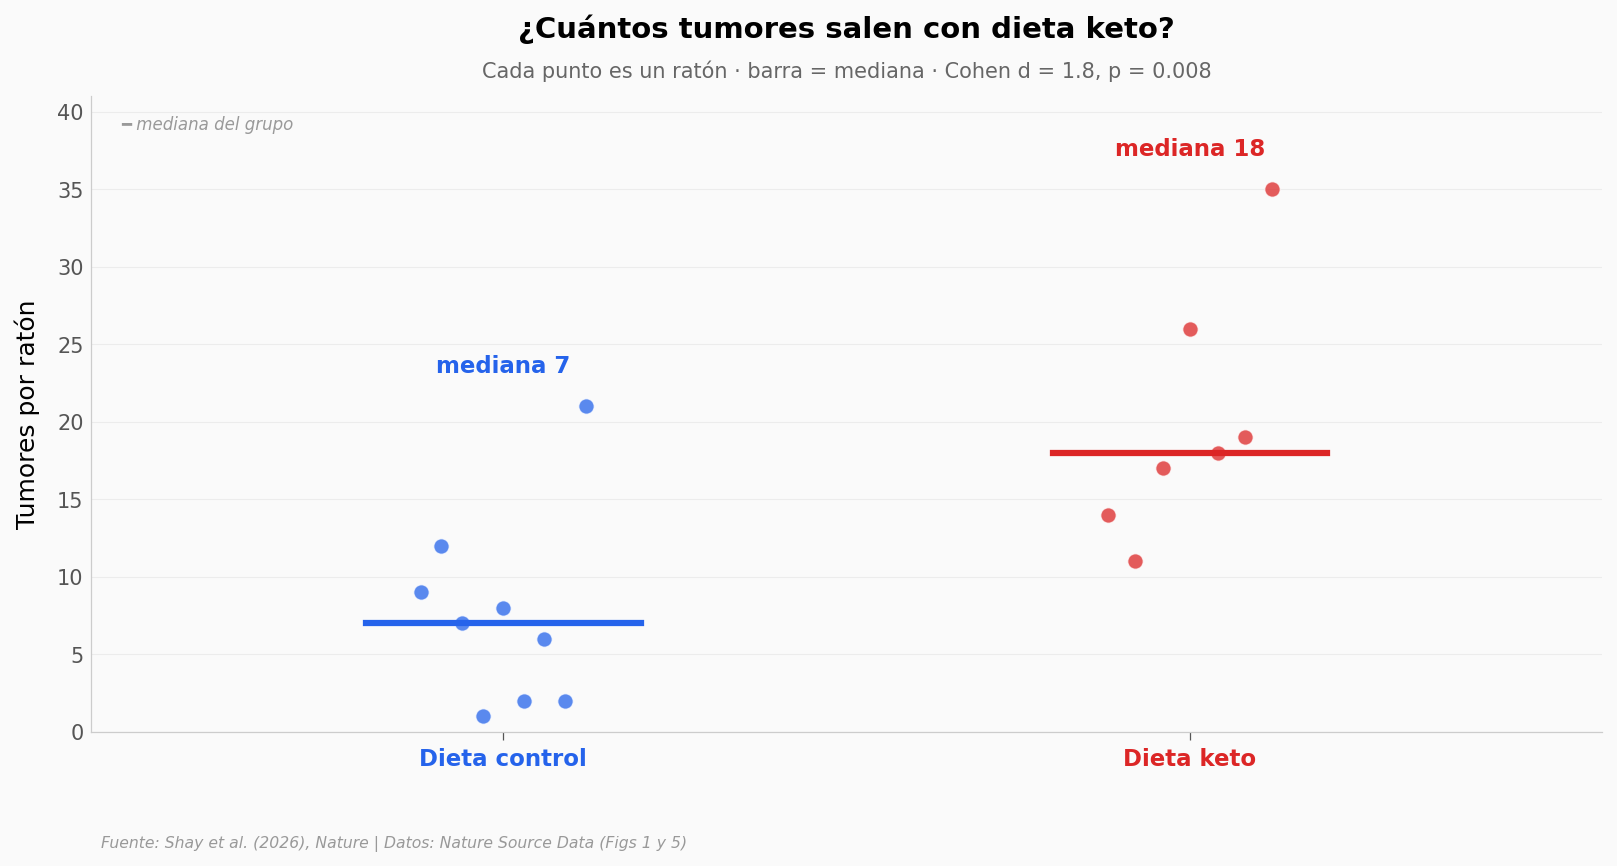

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))
np.random.seed(42)

grupos = [('Dieta control', tnum['CD'].dropna(), COLOR_CONTROL),
          ('Dieta keto',    tnum['KD'].dropna(), COLOR_KETO)]
posiciones = [0, 1]

for pos, (nombre, vals, color) in zip(posiciones, grupos):
    n = len(vals)
    x = np.linspace(pos - 0.12, pos + 0.12, n)
    np.random.shuffle(x)
    ax.scatter(x, vals, color=color, s=55, alpha=0.75,
               edgecolors='white', linewidths=0.6, zorder=5)
    m = vals.median()
    ax.plot([pos-0.2, pos+0.2], [m, m], color=color, lw=3, zorder=6)
    ax.text(pos, vals.max()+2.2, f'mediana {m:.0f}', ha='center',
            fontsize=11, fontweight='bold', color=color)

ax.set_xticks(posiciones)
ax.set_xticklabels(['Dieta control', 'Dieta keto'], fontsize=11, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), [COLOR_CONTROL, COLOR_KETO]):
    tick.set_color(color)
ax.set_ylabel('Tumores por ratón')
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0, tnum.max().max()+6)

fold, d, p = resumen('Nº de tumores (keto vs control)', tnum['KD'], tnum['CD'])
ax.set_title('¿Cuántos tumores salen con dieta keto?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Cada punto es un ratón · barra = mediana · Cohen d = {d:.1f}, p = {p:.3f}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.02, 0.97, '━ mediana del grupo', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='left', va='top', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tumores_keto_vs_control.png', dpi=200, bbox_inches='tight')
plt.show()

La nube keto vive más arriba: mediana de 18 tumores por ratón, contra 7 con la dieta control. Es un salto de unas 2,6 veces, y el tamaño de efecto (Cohen d = 1,8) es de los grandes — no es ruido de unos pocos ratones desafortunados.

Lo que llama la atención no es solo que suba, sino cuánto se separan los grupos: casi no se pisan. Con la dieta que muchos asocian a "salud metabólica", estos ratones —ya predispuestos— acumularon más del doble de tumores.

## Y no es solo la cuenta: crecen más y matan antes

Más tumores podría no importar si fueran diminutos. Veamos el área tumoral total, y en paralelo cuánto vivieron los ratones.

Área tumoral (keto vs control): mediana 4318073 vs 990262  (4.4x)  |  Cohen d = 2.53  |  Mann-Whitney p = 0.0007  |  n = 7 vs 9


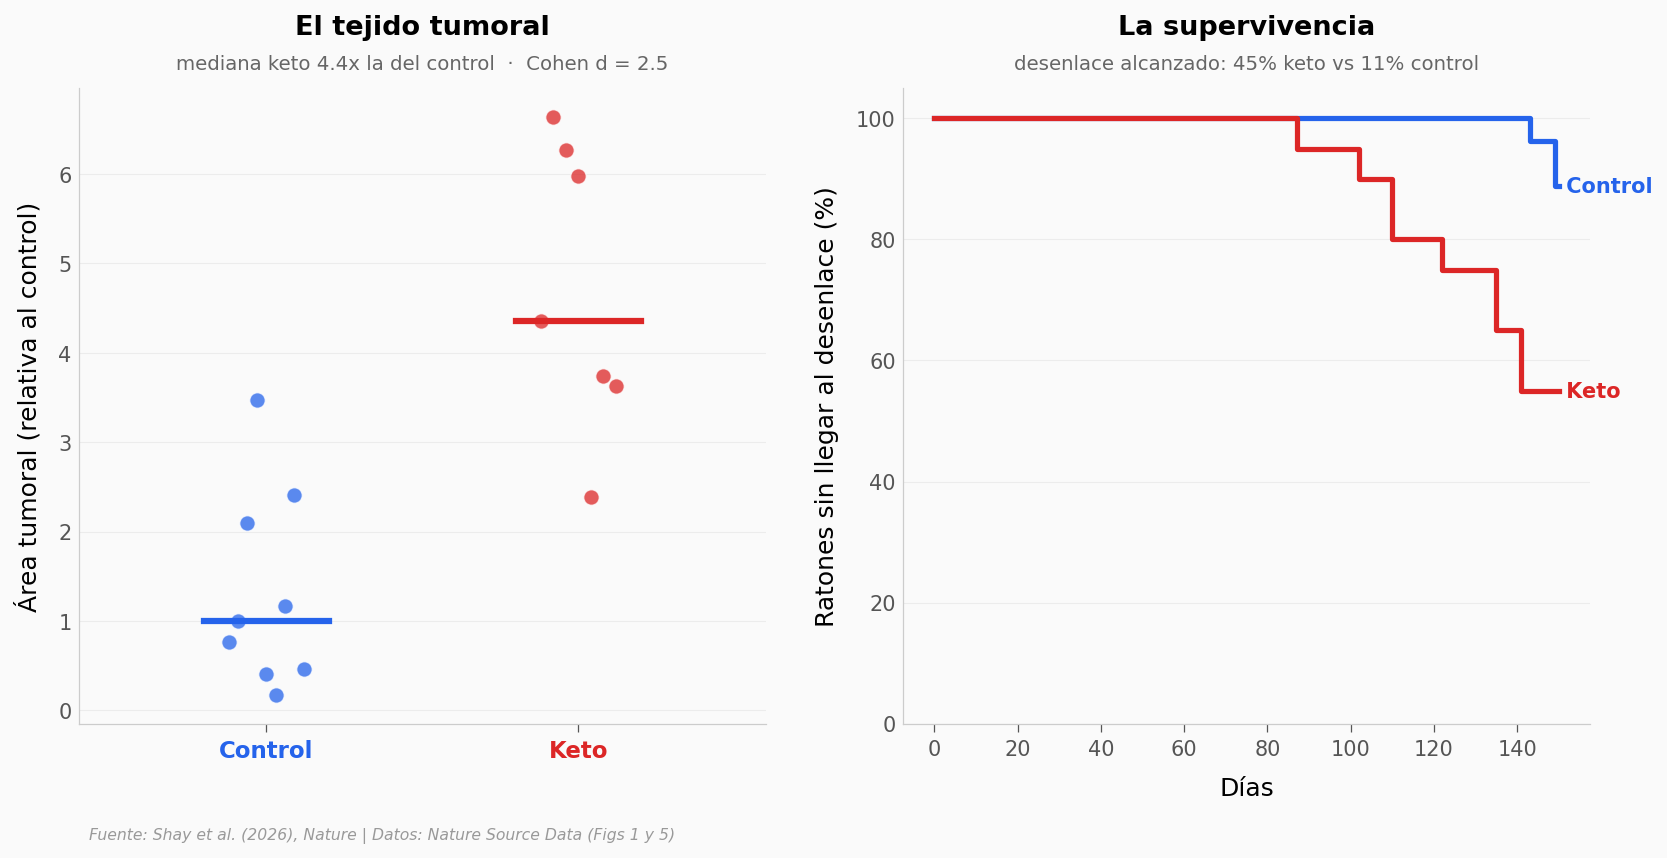

Área tumoral: keto ~4.4x la del control (p = 0.0007)
Supervivencia: 45% de los ratones keto alcanzó el desenlace de mortalidad, contra 11% en control


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
np.random.seed(42)

# ── Panel izquierdo: área tumoral, normalizada a la mediana del control ──
# (el dato crudo del paper viene en unidades de área sin etiqueta pública;
#  mostramos el fold-change, que es lo verificable desde los datos)
ref_cd = tarea['CD'].dropna().median()
cd_a = tarea['CD'].dropna() / ref_cd
kd_a = tarea['KD'].dropna() / ref_cd
for pos, (vals, color) in zip([0, 1], [(cd_a, COLOR_CONTROL), (kd_a, COLOR_KETO)]):
    x = np.linspace(pos-0.12, pos+0.12, len(vals)); np.random.shuffle(x)
    ax1.scatter(x, vals, color=color, s=55, alpha=0.75,
                edgecolors='white', linewidths=0.6, zorder=5)
    ax1.plot([pos-0.2, pos+0.2], [vals.median()]*2, color=color, lw=3, zorder=6)
ax1.set_xticks([0, 1]); ax1.set_xticklabels(['Control', 'Keto'], fontsize=11, fontweight='bold')
for t, c in zip(ax1.get_xticklabels(), [COLOR_CONTROL, COLOR_KETO]): t.set_color(c)
ax1.set_ylabel('Área tumoral (relativa al control)')
ax1.set_xlim(-0.6, 1.6)
fold_a, d_a, p_a = resumen('Área tumoral (keto vs control)', tarea['KD'], tarea['CD'])
ax1.set_title('El tejido tumoral', fontsize=13, fontweight='bold', pad=26)
ax1.text(0.5, 1.03, f'mediana keto {kd_a.median():.1f}x la del control  ·  Cohen d = {d_a:.1f}',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')

# ── Panel derecho: supervivencia KD vs CD (curva escalonada) ──
def curva_km(df, grupo):
    d = df[df.group == grupo].sort_values('days_elapsed')
    n = len(d); t = [0]; s = [1.0]; vivos = n
    for _, row in d.iterrows():
        if row.event == 1:
            vivos -= 1
            t.append(row.days_elapsed); s.append(vivos / n)
    t.append(d.days_elapsed.max()); s.append(vivos / n)
    return t, s

for grupo, color, etq in [('CD', COLOR_CONTROL, 'Control'), ('KD', COLOR_KETO, 'Keto')]:
    t, s = curva_km(surv, grupo)
    ax2.step([x for x in t], [y*100 for y in s], where='post', color=color, lw=2.5)
    ax2.text(t[-1], s[-1]*100, f' {etq}', color=color, fontsize=10,
             fontweight='bold', va='center')
ax2.set_xlabel('Días'); ax2.set_ylabel('Ratones sin llegar al desenlace (%)')
ax2.set_ylim(0, 105)
ev_kd = surv[(surv.group=='KD')].event.mean()*100
ev_cd = surv[(surv.group=='CD')].event.mean()*100
ax2.set_title('La supervivencia', fontsize=13, fontweight='bold', pad=26)
ax2.text(0.5, 1.03, f'desenlace alcanzado: {ev_kd:.0f}% keto vs {ev_cd:.0f}% control',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/area_y_supervivencia.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Área tumoral: keto ~{tarea['KD'].dropna().median()/tarea['CD'].dropna().median():.1f}x la del control (p = {p_a:.4f})")
print(f"Supervivencia: {ev_kd:.0f}% de los ratones keto alcanzó el desenlace de mortalidad, contra {ev_cd:.0f}% en control")

## El giro: no eran las cetonas

Lo lógico sería culpar a las cetonas — son lo que define a la dieta keto. Así que el equipo las manipuló directamente: apagaron *HMGCS2* (la enzima que fabrica cetonas) y también la ruta que las quema.

Y los tumores **no se movieron**. Subir o bajar las cetonas no cambió la tumorigénesis. Ese resultado nulo es la pieza clave: descarta al sospechoso obvio.

¿Qué queda? La otra cosa que abunda en una dieta keto: **grasa**. Y no la grasa acumulada, sino la que las células *queman* para sacar energía — la oxidación de ácidos grasos, cuya puerta de entrada es la enzima **CPT1A**. El equipo la apagó (ratones *Cpt1a-iKO*) y repitió el experimento bajo dieta keto.

Área tumoral bajo keto (con vs sin CPT1A): mediana 7276208 vs 4331845  (1.7x)  |  Cohen d = 1.45  |  Mann-Whitney p = 0.0013  |  n = 12 vs 30


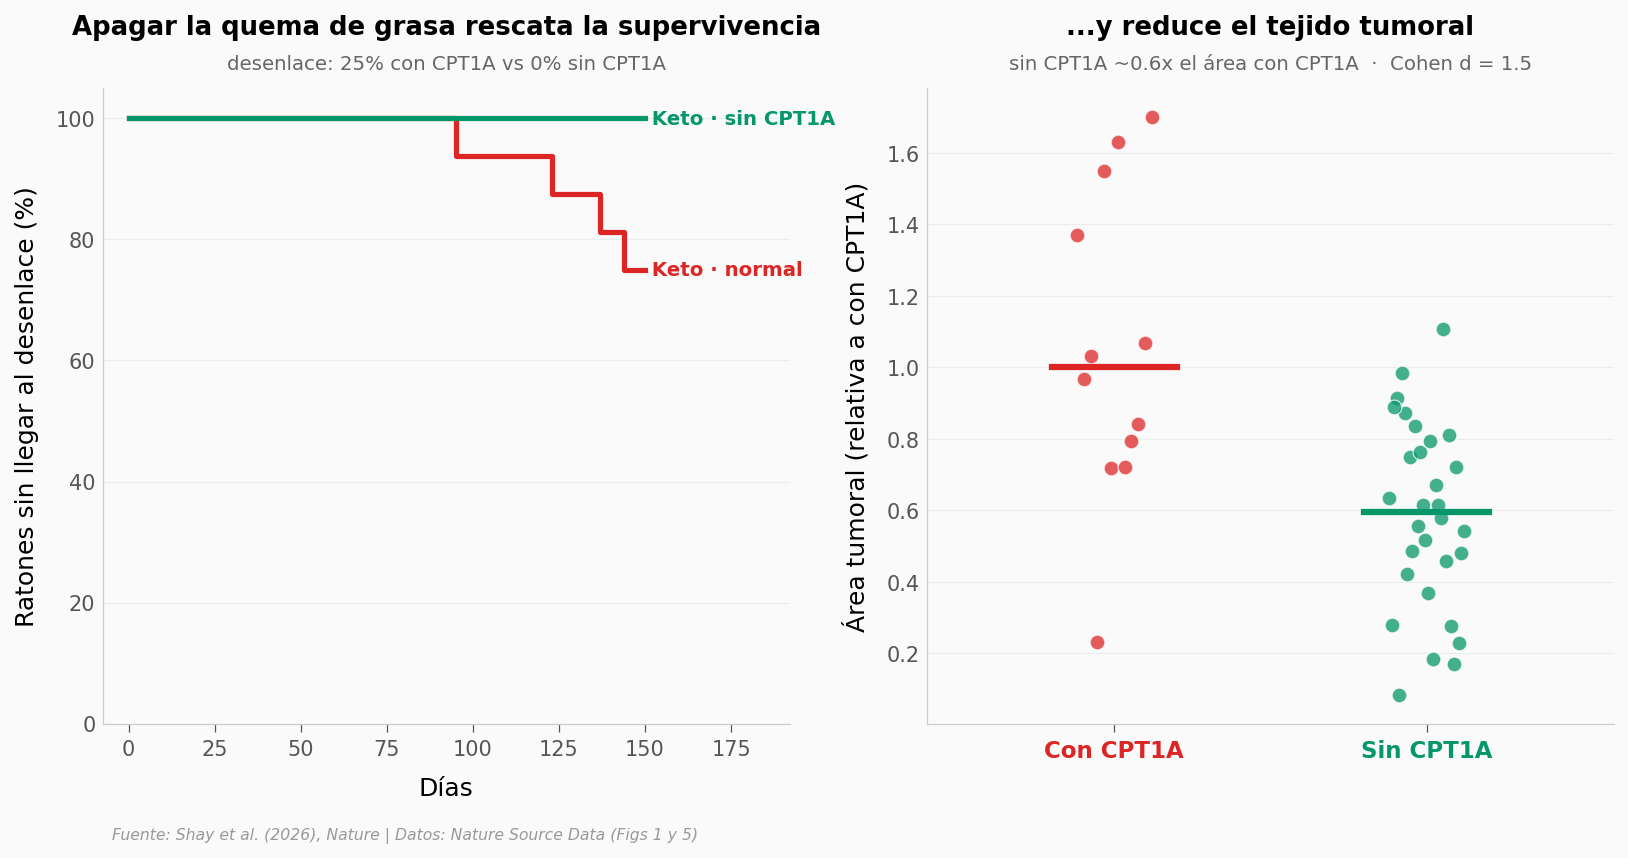

Sin CPT1A, bajo la MISMA dieta keto: 0% alcanzó el desenlace (todos sobrevivieron) frente al 25% con CPT1A intacta.
Área tumoral: sin CPT1A baja a ~1/1.7 (p = 0.0013).


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
np.random.seed(42)

# ── Panel izquierdo: supervivencia WT vs Cpt1a-iKO (ambos bajo KD) ──
for grupo, color, etq in [('KD-WT', COLOR_KETO, 'Keto · normal'),
                          ('KD-Cpt1a-iKO', COLOR_RESCATE, 'Keto · sin CPT1A')]:
    t, s = curva_km(c_srv, grupo)
    ax1.step(t, [y*100 for y in s], where='post', color=color, lw=2.5)
    ax1.text(t[-1], s[-1]*100, f' {etq}', color=color, fontsize=9.5, fontweight='bold', va='center')
ax1.set_xlabel('Días'); ax1.set_ylabel('Ratones sin llegar al desenlace (%)')
ax1.set_ylim(0, 105); ax1.set_xlim(right=c_srv.days_elapsed.max()*1.28)
ev_wt = c_srv[c_srv.group=='KD-WT'].event.mean()*100
ev_ko = c_srv[c_srv.group=='KD-Cpt1a-iKO'].event.mean()*100
ax1.set_title('Apagar la quema de grasa rescata la supervivencia',
              fontsize=12.5, fontweight='bold', pad=26)
ax1.text(0.5, 1.03, f'desenlace: {ev_wt:.0f}% con CPT1A vs {ev_ko:.0f}% sin CPT1A',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')

# ── Panel derecho: área tumoral WT vs iKO, normalizada a la mediana WT ──
ref_wt = c_area['KD-WT'].dropna().median()
wt_a = c_area['KD-WT'].dropna() / ref_wt
ko_a = c_area['KD-Cpt1a-iKO'].dropna() / ref_wt
for pos, (vals, color) in zip([0, 1], [(wt_a, COLOR_KETO), (ko_a, COLOR_RESCATE)]):
    x = np.linspace(pos-0.12, pos+0.12, len(vals)); np.random.shuffle(x)
    ax2.scatter(x, vals, color=color, s=50, alpha=0.75,
                edgecolors='white', linewidths=0.6, zorder=5)
    ax2.plot([pos-0.2, pos+0.2], [vals.median()]*2, color=color, lw=3, zorder=6)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Con CPT1A', 'Sin CPT1A'], fontsize=11, fontweight='bold')
for t_, c_ in zip(ax2.get_xticklabels(), [COLOR_KETO, COLOR_RESCATE]): t_.set_color(c_)
ax2.set_ylabel('Área tumoral (relativa a con CPT1A)'); ax2.set_xlim(-0.6, 1.6)
fold_c, d_c, p_c = resumen('Área tumoral bajo keto (con vs sin CPT1A)', c_area['KD-WT'], c_area['KD-Cpt1a-iKO'])
ax2.set_title('...y reduce el tejido tumoral', fontsize=12.5, fontweight='bold', pad=26)
ax2.text(0.5, 1.03, f'sin CPT1A ~{ko_a.median():.1f}x el área con CPT1A  ·  Cohen d = {d_c:.1f}',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rescate_cpt1a.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Sin CPT1A, bajo la MISMA dieta keto: {ev_ko:.0f}% alcanzó el desenlace (todos sobrevivieron) "
      f"frente al {ev_wt:.0f}% con CPT1A intacta.")
print(f"Área tumoral: sin CPT1A baja a ~1/{wt_a.median()/ko_a.median():.1f} (p = {p_c:.4f}).")

## ¿Qué tan grande es cada efecto?

Los porcentajes y las medianas cuentan la historia, pero el tamaño de efecto (Cohen d) las pone en una misma regla: cuántas desviaciones estándar separan a los grupos. Pongámoslas lado a lado.

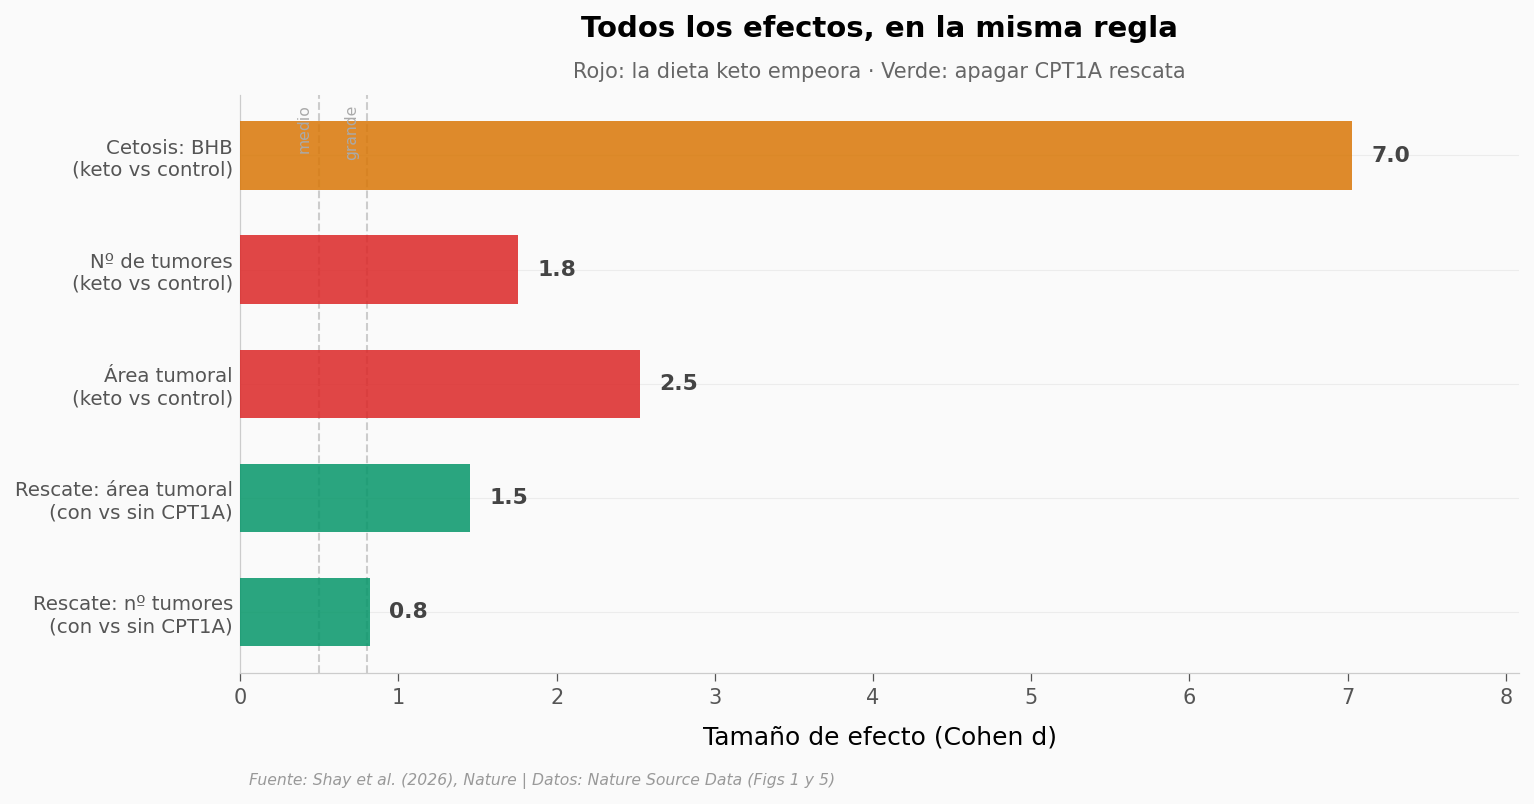

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

comparaciones = [
    ('Cetosis: BHB\n(keto vs control)',        cohen_d(kd_bhb, cd_bhb),                        COLOR_REF),
    ('Nº de tumores\n(keto vs control)',       cohen_d(tnum['KD'].dropna(), tnum['CD'].dropna()), COLOR_KETO),
    ('Área tumoral\n(keto vs control)',        cohen_d(tarea['KD'].dropna(), tarea['CD'].dropna()), COLOR_KETO),
    ('Rescate: área tumoral\n(con vs sin CPT1A)', cohen_d(c_area['KD-WT'].dropna(), c_area['KD-Cpt1a-iKO'].dropna()), COLOR_RESCATE),
    ('Rescate: nº tumores\n(con vs sin CPT1A)', cohen_d(c_num['KD-WT'].dropna(), c_num['KD-Cpt1a-iKO'].dropna()), COLOR_RESCATE),
]
etiquetas = [c[0] for c in comparaciones]
valores   = [c[1] for c in comparaciones]
colores   = [c[2] for c in comparaciones]

y = np.arange(len(comparaciones))[::-1]
ax.barh(y, valores, color=colores, alpha=0.85, height=0.6, zorder=3)
for yi, v in zip(y, valores):
    ax.text(v + 0.12, yi, f'{v:.1f}', va='center', fontsize=10.5, fontweight='bold', color='#444444')

# Bandas de referencia de tamaño de efecto (convención de Cohen)
for x_ref, txt in [(0.5, 'medio'), (0.8, 'grande')]:
    ax.axvline(x_ref, color='#CCCCCC', lw=1, linestyle='--', zorder=1)
    ax.text(x_ref - 0.05, len(comparaciones)-0.55, txt, fontsize=7.5, color='#AAAAAA',
            ha='right', va='top', rotation=90)

ax.set_yticks(y); ax.set_yticklabels(etiquetas, fontsize=9.5)
ax.set_xlabel('Tamaño de efecto (Cohen d)')
ax.set_xlim(0, max(valores)*1.15)
ax.set_title('Todos los efectos, en la misma regla', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Rojo: la dieta keto empeora · Verde: apagar CPT1A rescata',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tamanos_de_efecto.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La dieta indujo cetosis real | ✅ | BHB ~9x más alto con keto (Cohen d ≈ 7,0; p = 0,003; n = 7 vs 5). Escala normalizada de intensidad, no mM: solo interpretamos el fold-change. |
| La keto aumenta el número de tumores | ✅ | Mediana 18 vs 7 (~2,6x). Cohen d = 1,8; Mann-Whitney p = 0,008; n = 7 vs 9. |
| La keto aumenta el área tumoral | ✅ | ~4x la mediana del control. Cohen d = 2,5; p = 0,0007. |
| La keto acorta la supervivencia | ✅ | 45% de los ratones keto alcanzó el desenlace de mortalidad vs 11% en control (n = 20 vs 27). Análisis descriptivo, sin test formal de hazard aquí. |
| El efecto **no** viene de las cetonas | ✅ | Resultado nulo del paper: modular *HMGCS2* / la ketólisis no cambió la tumorigénesis (dato reportado en el artículo; no reanalizado en este notebook). |
| Apagar la oxidación de grasas (CPT1A) rescata | ✅/⚠️ | Fuerte en supervivencia (0% de eventos sin CPT1A vs 25% con CPT1A) y en área (Cohen d = 1,5; p = 0,001). Moderado en número de tumores (Cohen d = 0,8; p = 0,038). |

> **Limitaciones:**
> - Todo es en **ratones** con mutación *Apc* (modelo de poliposis familiar, FAP). No es evidencia de que la dieta keto cause cáncer en humanos sanos.
> - El BHB está en unidades normalizadas de intensidad, no en concentración: sirve para confirmar cetosis por fold-change, no como valor absoluto.
> - La supervivencia se resume de forma descriptiva (% de eventos, días); no calculamos aquí un hazard ratio ni intervalos de confianza.
> - El resultado nulo sobre cetonas y los knockouts genéticos se toman del paper; este notebook reanaliza los datos de tumores, área y supervivencia (Figs 1 y 5).

## Ahora tú

Los datos están cargados. Tres preguntas para hurgar:

1. **¿Y si comparas medias en vez de medianas?** El área tumoral está muy sesgada (unos pocos tumores gigantes). ¿Cambia el fold-change si usas `.mean()` en lugar de `.median()`? ¿Cuál describe mejor a un ratón "típico"?
2. **¿Aguanta la significancia con tan pocos ratones?** Prueba un test de permutación para el número de tumores: mezcla las etiquetas keto/control 10.000 veces y mira cuántas veces la diferencia de medianas iguala o supera la real.
3. **¿El rescate del CPT1A es igual de nítido en número que en área?** Compara los Cohen d de las dos gráficas del rescate. ¿Por qué uno es "grande" y el otro solo "moderado"?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Test de permutación: ¿qué tan raro es ver una diferencia de medianas
# tan grande como la real, si la dieta no importara?

np.random.seed(0)
kd = tnum['KD'].dropna().values
cd = tnum['CD'].dropna().values
dif_real = np.median(kd) - np.median(cd)

juntos = np.concatenate([kd, cd])
n_kd = len(kd)
difs = []
for _ in range(10000):
    np.random.shuffle(juntos)
    difs.append(np.median(juntos[:n_kd]) - np.median(juntos[n_kd:]))
difs = np.array(difs)
p_perm = (np.abs(difs) >= abs(dif_real)).mean()

print(f"Diferencia real de medianas (keto − control): {dif_real:.0f} tumores")
print(f"p por permutación (10.000 barajadas): {p_perm:.4f}")
print("→ Aun barajando las etiquetas al azar, casi nunca aparece una brecha así de grande.")

Diferencia real de medianas (keto − control): 11 tumores
p por permutación (10.000 barajadas): 0.0325
→ Aun barajando las etiquetas al azar, casi nunca aparece una brecha así de grande.


---

## Créditos

- **Paper:** Shay et al. (2026), *Ketogenic diet mediates intestinal tumorigenesis through lipids not ketones*, **Nature**. DOI: [10.1038/s41586-026-10779-y](https://doi.org/10.1038/s41586-026-10779-y)
- **Datos:** Nature Source Data (Figs 1 y 5), archivos MOESM del propio artículo.
- **Licencia del análisis:** notebook reproducible de Ciencia a Mordiscos.
- **Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

## Fuentes

**Paper**: [Ketogenic diet mediates intestinal tumorigenesis through lipids not ketones](https://doi.org/10.1038/s41586-026-10779-y)  
*Nature, 2026-07-15*

**Datos**: [Source Data Figs 1 & 5 - Ketogenic diet mediates intestinal tumorigenesis](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10779-y/MediaObjects/41586_2026_10779_MOESM3_ESM.xlsx)  
*Nature (Source Data) — Figs 1 y 5*

**Referencias citadas**: [Lipidomics data (project PR003051)](https://doi.org/10.21228/M89G3N) (Metabolomics Workbench)

*14 afirmaciones del notebook verificadas contra estas fuentes*